 ### Task-1
 - Load the dataset 
 - Check for missing values and duplicates
 - Impute missing numerical columns using the appropriate measure of central tendency based on skewness, and remove duplicate rows.

In [218]:
import pandas as pd

In [219]:
df = pd.read_csv(r"C:\ProgFiles\IIT-PATNA\Dataset\used_cars_messy.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0


In [220]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  str    
 2   brand              15661 non-null  str    
 3   model              15661 non-null  str    
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  str    
 6   seller_type        15661 non-null  str    
 7   fuel_type          15661 non-null  str    
 8   transmission_type  15661 non-null  str    
 9   mileage            14376 non-null  str    
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), str(8)
memory usage: 1.7 MB


In [221]:
df.isnull().sum()

Unnamed: 0              0
car_name                0
brand                   0
model                   0
vehicle_age             0
km_driven               0
seller_type             0
fuel_type               0
transmission_type       0
mileage              1285
engine               1869
max_power             799
seats                 443
selling_price         158
dtype: int64

In [222]:
df[df.duplicated(keep=False)]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
161,4246,Tata Safari,Tata,Safari,9,100000,Individual,Diesel,Manual,11.57,2179.0,138.10,7.0,260000.0
174,4763,Skoda Rapid,Skoda,Rapid,6,55300,Dealer,Diesel,Automatic,21.66,1498.0,103.52,5.0,650000.0
202,14596,Maruti Alto,Maruti,Alto,2,25000,Individual,Petrol,Manual,24.7,796.0,47.30,5.0,300000.0
285,7096,Hyundai i10,Hyundai,i10,11,52000,Dealer,Petrol,Manual,NaN,1197.0,78.90,5.0,280000.0
293,646,Honda Amaze,Honda,Amaze,3,50000,Individual,Petrol,Manual,17.8,1198.0,86.70,5.0,550000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15437,6814,Hyundai i10,Hyundai,i10,7,89800,Dealer,Petrol,Manual,20.36,1197.0,78.90,5.0,275000.0
15438,17972,Mahindra XUV500,Mahindra,XUV500,8,95000,Dealer,Diesel,Manual,15.1,2179.0,140.00,7.0,825000.0
15514,4543,Toyota Innova,Toyota,Innova,12,200000,Individual,Diesel,Manual,12.8,2494.0,102.00,7.0,480000.0
15524,18228,Mahindra XUV500,Mahindra,XUV500,9,80000,Individual,Diesel,Manual,15.1,2179.0,140.00,7.0,875000.0


In [223]:
df.drop_duplicates(inplace=True)

In [224]:
df = df.drop(columns=['Unnamed: 0'])
print(f"Shape after dropping Unnamed: 0: {df.shape}")

Shape after dropping Unnamed: 0: (15492, 13)


In [225]:
print(f"Unique brands BEFORE cleaning: {df['brand'].nunique()}")

df['brand'] = df['brand'].str.strip()

print(f"Unique brands AFTER cleaning: {df['brand'].nunique()}")
print(f"\nTop 10 brands:")
print(df['brand'].value_counts().head(10))

Unique brands BEFORE cleaning: 80
Unique brands AFTER cleaning: 32

Top 10 brands:
brand
Maruti        5019
Hyundai       2997
Honda         1494
Mahindra      1013
Toyota         797
Ford           794
Volkswagen     623
Renault        543
BMW            441
Tata           432
Name: count, dtype: int64


In [226]:
print(f"Unique fuel types BEFORE: {df['fuel_type'].nunique()}")
print(sorted(df['fuel_type'].unique()))

df['fuel_type'] = df['fuel_type'].str.strip().str.title()

print(f"\nUnique fuel types AFTER: {df['fuel_type'].nunique()}")
print(sorted(df['fuel_type'].unique()))

Unique fuel types BEFORE: 14
[' Diesel', ' Petrol', 'CNG', 'DIESEL', 'Diesel', 'Electric', 'LPG', 'PETROL', 'Petrol', 'Petrol ', 'diesel', 'diesel ', 'petrol', 'petrol ']

Unique fuel types AFTER: 5
['Cng', 'Diesel', 'Electric', 'Lpg', 'Petrol']


In [227]:
print(f"Unique seller types BEFORE: {df['seller_type'].nunique()}")
print(sorted(df['seller_type'].unique()))

df['seller_type'] = df['seller_type'].str.strip().str.title()

print(f"\nAfter strip+title: {df['seller_type'].nunique()} unique")
print(sorted(df['seller_type'].unique()))

typo_map = {
    'Individul': 'Individual',
    'Individuall': 'Individual',
    'Delaer': 'Dealer',
    'Trustmark Delaer': 'Trustmark Dealer'
}
df['seller_type'] = df['seller_type'].replace(typo_map)

print(f"\nFinal unique seller types: {df['seller_type'].nunique()}")
print(df['seller_type'].value_counts())

Unique seller types BEFORE: 9
['DEALER', 'Dealer', 'Delaer', 'Individual', 'Individuall', 'Individul', 'Trustmark Dealer', 'dealer', 'individual']

After strip+title: 6 unique
['Dealer', 'Delaer', 'Individual', 'Individuall', 'Individul', 'Trustmark Dealer']

Final unique seller types: 3
seller_type
Dealer              9585
Individual          5734
Trustmark Dealer     173
Name: count, dtype: int64


In [228]:
df['km_driven'] = df['km_driven'].astype(str).str.replace(',', '', regex=False)
df['km_driven'] = df['km_driven'].str.replace(r'\s*(kms|km)\s*', '', regex=True)
df['km_driven'] = pd.to_numeric(df['km_driven'], errors='coerce')

print(f"km_driven dtype: {df['km_driven'].dtype}")
print(f"Sample values: {df['km_driven'].head(10).tolist()}")

km_driven dtype: int64
Sample values: [67647, 52000, 48959, 82000, 34000, 73000, 88000, 50000, 30000, 75220]


In [229]:
df['mileage'] = df['mileage'].astype(str).str.replace(r'\s*kmpl\s*', '', regex=True)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

print(f"mileage dtype: {df['mileage'].dtype}")
print(f"Sample values: {df['mileage'].dropna().head(10).tolist()}")

mileage dtype: float64
Sample values: [19.87, 33.54, 15.4, 16.0, 20.36, 18.5, 20.51, 24.4, 19.3, 16.1]


In [230]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(1),
    'Dtype': df.dtypes
})
print(missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False))

               Missing Count  Missing %    Dtype
engine                  1848       11.9  float64
mileage                 1270        8.2  float64
max_power                788        5.1  float64
seats                    439        2.8  float64
selling_price            156        1.0  float64


In [231]:
before = len(df)
df = df.dropna(subset=['selling_price'])
after = len(df)
print(f"Dropped {before - after} rows where selling_price was missing")
print(f"Remaining rows: {after}")

Dropped 156 rows where selling_price was missing
Remaining rows: 15336


In [232]:
print("Engine distribution:")
print(f"  Mean:   {df['engine'].mean():.0f} cc")
print(f"  Median: {df['engine'].median():.0f} cc")
print(f"  Skew:   {df['engine'].skew():.2f}")

print("\nMax Power distribution:")
print(f"  Mean:   {df['max_power'].mean():.1f} bhp")
print(f"  Median: {df['max_power'].median():.1f} bhp")
print(f"  Skew:   {df['max_power'].skew():.2f}")

Engine distribution:
  Mean:   1481 cc
  Median: 1248 cc
  Skew:   1.66

Max Power distribution:
  Mean:   100.6 bhp
  Median: 88.5 bhp
  Skew:   2.51


In [233]:
for col in ['engine', 'mileage', 'max_power']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} missing values with median: {median_val}")

seats_mode = df['seats'].mode()[0]
df['seats'] = df['seats'].fillna(seats_mode)
print(f"Filled seats missing values with mode: {seats_mode}")

print(f"\nRemaining missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
if df.isnull().sum().sum() == 0:
    print("\n✅ No missing values remaining!")

Filled engine missing values with median: 1248.0
Filled mileage missing values with median: 19.67
Filled max_power missing values with median: 88.5
Filled seats missing values with mode: 5.0

Remaining missing values:
Series([], dtype: int64)

✅ No missing values remaining!


In [234]:
df.info()

<class 'pandas.DataFrame'>
Index: 15336 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15336 non-null  str    
 1   brand              15336 non-null  str    
 2   model              15336 non-null  str    
 3   vehicle_age        15336 non-null  int64  
 4   km_driven          15336 non-null  int64  
 5   seller_type        15336 non-null  str    
 6   fuel_type          15336 non-null  str    
 7   transmission_type  15336 non-null  str    
 8   mileage            15336 non-null  float64
 9   engine             15336 non-null  float64
 10  max_power          15336 non-null  float64
 11  seats              15336 non-null  float64
 12  selling_price      15336 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory usage: 1.6 MB


In [235]:
# Remove clearly erroneous prices
before = len(df)
print(before)

# Remove the 999999999 entries (data entry errors)
df = df[df['selling_price'] != 999999999]

# Remove suspiciously low prices (< ₹10,000 for a car is not realistic)
df = df[df['selling_price'] >= 10000]

# Also fix seats = 0 (impossible)
df = df[df['seats'] > 0]

after = len(df)
print(f"Removed {before - after} rows with impossible values")
print(f"Remaining rows: {after}")

15336
Removed 10 rows with impossible values
Remaining rows: 15326


In [236]:
df = df.drop(columns=['car_name', 'model'])

In [237]:
from sklearn.preprocessing import LabelEncoder

In [238]:
le = LabelEncoder()

df['transmission_type'] = le.fit_transform(df['transmission_type'])

In [239]:
df = pd.get_dummies(df, columns=["seller_type", "fuel_type"], drop_first=True)

In [240]:
brand_counts = df['brand'].value_counts()
print(brand_counts)

print("Number of cars brands with <100 cars are: ", (brand_counts < 100).sum())

brand
Maruti           4959
Hyundai          2972
Honda            1479
Mahindra          998
Toyota            791
Ford              784
Volkswagen        615
Renault           533
BMW               438
Tata              430
Mercedes-Benz     335
Skoda             331
Audi              191
Datsun            169
Jaguar             59
Land Rover         51
Jeep               42
Kia                32
Porsche            22
Volvo              20
MG                 19
Mini               17
Lexus              10
Nissan             10
Isuzu               8
Bentley             3
Maserati            2
ISUZU               2
Mercedes-AMG        1
Ferrari             1
Force               1
Rolls-Royce         1
Name: count, dtype: int64
Number of cars brands with <100 cars are:  18


In [241]:
rare_brands = brand_counts[brand_counts < 100].index.to_list()

print(f"Grouping {(len(rare_brands))} into other: {rare_brands}")

df['brand'] = df['brand'].replace(rare_brands, "Other")

df['brand'].value_counts()

Grouping 18 into other: ['Jaguar', 'Land Rover', 'Jeep', 'Kia', 'Porsche', 'Volvo', 'MG', 'Mini', 'Lexus', 'Nissan', 'Isuzu', 'Bentley', 'Maserati', 'ISUZU', 'Mercedes-AMG', 'Ferrari', 'Force', 'Rolls-Royce']


brand
Maruti           4959
Hyundai          2972
Honda            1479
Mahindra          998
Toyota            791
Ford              784
Volkswagen        615
Renault           533
BMW               438
Tata              430
Mercedes-Benz     335
Skoda             331
Other             301
Audi              191
Datsun            169
Name: count, dtype: int64

In [242]:
df = pd.get_dummies(df, columns=["brand"], drop_first=True)

In [243]:
df.info()

<class 'pandas.DataFrame'>
Index: 15326 entries, 0 to 15660
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   vehicle_age                   15326 non-null  int64  
 1   km_driven                     15326 non-null  int64  
 2   transmission_type             15326 non-null  int64  
 3   mileage                       15326 non-null  float64
 4   engine                        15326 non-null  float64
 5   max_power                     15326 non-null  float64
 6   seats                         15326 non-null  float64
 7   selling_price                 15326 non-null  float64
 8   seller_type_Individual        15326 non-null  bool   
 9   seller_type_Trustmark Dealer  15326 non-null  bool   
 10  fuel_type_Diesel              15326 non-null  bool   
 11  fuel_type_Electric            15326 non-null  bool   
 12  fuel_type_Lpg                 15326 non-null  bool   
 13  fuel_type_Petrol 

In [244]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [245]:
X = df.drop("selling_price", axis=1)
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Length of training data: {X_train.shape}")
print(f"Length of testing data: {X_test.shape}")

Length of training data: (12260, 27)
Length of testing data: (3066, 27)


In [246]:
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

print("Numeric columns to scale:")
print(X_train[numeric_cols].describe().round(1))
print("\nNotice the wildly different ranges — this is why we need scaling!")

Numeric columns to scale:


       vehicle_age  km_driven  mileage   engine  max_power    seats
count      12260.0    12260.0  12260.0  12260.0    12260.0  12260.0
mean           6.0    55313.7     19.7   1451.6       99.8      5.3
std            3.0    52869.7      4.0    485.5       41.7      0.8
min            0.0      100.0      4.0    793.0       38.4      2.0
25%            4.0    30000.0     17.0   1197.0       74.0      5.0
50%            6.0    50000.0     19.7   1248.0       88.5      5.0
75%            8.0    70000.0     22.3   1498.0      112.0      5.0
max           29.0  3800000.0     33.5   5998.0      626.0      9.0

Notice the wildly different ranges — this is why we need scaling!


In [247]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [248]:
import matplotlib.pyplot as plt

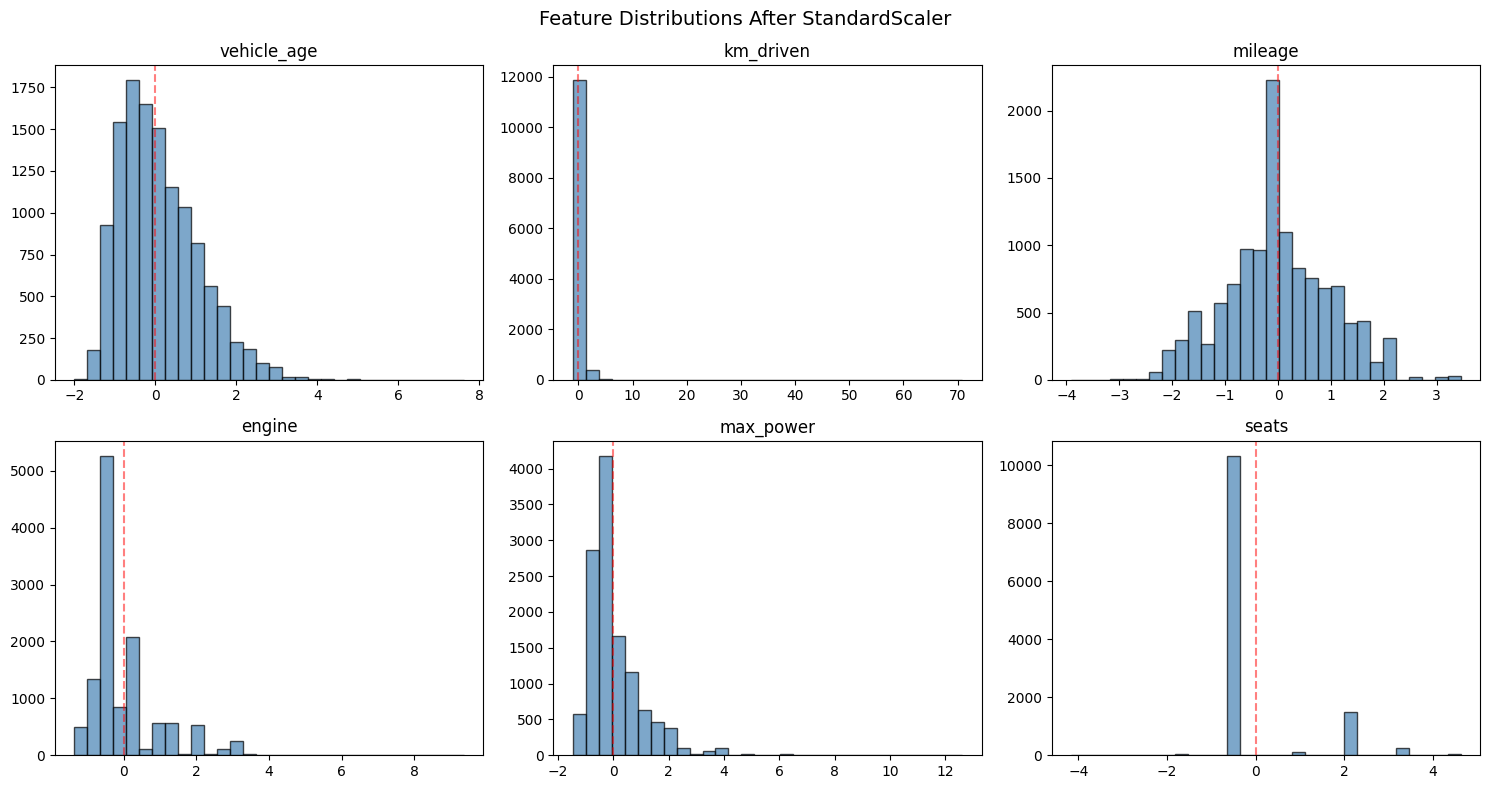

In [249]:
# Visual comparison: before vs after scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions After StandardScaler', fontsize=14)

for i, col in enumerate(numeric_cols):
    row, col_idx = i // 3, i % 3
    axes[row][col_idx].hist(X_train[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[row][col_idx].set_title(col)
    axes[row][col_idx].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()